# CS334 Data Science — Checkpoint 4
## Anime Recommendation Dataset

**Research Question:** What structural attributes significantly influence anime ratings, and can we identify meaningful anime archetypes through clustering?

This notebook covers the complete analysis pipeline — from data loading and exploratory analysis through to statistical modeling:
1. **Data Loading & Cleaning** — Preparing the dataset for analysis
2. **Exploratory Data Analysis** — Understanding rating distributions, formats, genres, episode length, and popularity
3. **T-test** — Do TV series and Movies differ significantly in average rating?
4. **Linear Regression** — Which structural features (episodes, popularity, type, genre) predict anime rating?
5. **K-Means Clustering** — Can we identify distinct anime archetypes based on rating, popularity, and episode count?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

## Section 1: Load Dataset

We load the Anime Recommendation Dataset from Kaggle. The dataset consists of two files: anime metadata (anime.csv) and individual user ratings (rating.csv).

In [3]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d CooperUnion/anime-recommendations-database
!unzip -o anime-recommendations-database.zip

anime = pd.read_csv("anime.csv")
ratings = pd.read_csv("rating.csv")

print("Anime dataset shape:", anime.shape)
print("Ratings dataset shape:", ratings.shape)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database
License(s): CC0-1.0
100% 25.0M/25.0M [00:00<00:00, 53.3MB/s]

Archive:  anime-recommendations-database.zip
  inflating: anime.csv               
  inflating: rating.csv              
Anime dataset shape: (12294, 7)
Ratings dataset shape: (7813737, 3)


## Section 2: Initial Dataset Inspection

We begin with a structural overview of the dataset before any cleaning. Missing values are present in `genre` (62), `type` (25), and `rating` (230). The `episodes` column is stored as a string due to "Unknown" entries and will need to be converted to numeric.


In [4]:

anime.info()
anime.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


## Section 4: Clean `episodes` Column

"Unknown" episode counts are replaced with `NaN` and the column is converted to numeric. This is necessary to treat episode count as a quantitative variable in later analyses.


In [5]:
# --------------------------------------------------
# Section 4: Clean 'episodes' Column
# Replace 'Unknown' with NaN and convert to numeric
# --------------------------------------------------

anime["episodes"] = anime["episodes"].replace("Unknown", np.nan)
anime["episodes"] = pd.to_numeric(anime["episodes"], errors="coerce")

anime["episodes"].isnull().sum()

np.int64(340)

## Section 5: Handle Missing Values

Since `rating` is our outcome variable, rows with missing ratings are dropped. Missing `genre` and `type` values are filled with "Unknown" so those rows remain available for non-genre and non-type analyses.


In [6]:

rows_before = len(anime)

# Drop rows with missing rating (needed for EDA comparisons)
anime = anime.dropna(subset=["rating"])

rows_after = len(anime)
print(f"Rows removed due to missing rating: {rows_before - rows_after}")
print(f"Dataset size after cleaning: {rows_after} anime")

# Replace missing genres with Unknown
missing_genre = anime["genre"].isna().sum()
anime["genre"] = anime["genre"].fillna("Unknown")
print(f"Missing genres filled with 'Unknown': {missing_genre}")

# Replace missing type with Unknown
missing_type = anime["type"].isna().sum()
anime["type"] = anime["type"].fillna("Unknown")
print(f"Missing types filled with 'Unknown': {missing_type}")

anime.isnull().sum()


Rows removed due to missing rating: 230
Dataset size after cleaning: 12064 anime
Missing genres filled with 'Unknown': 47
Missing types filled with 'Unknown': 0


,0
anime_id,0
name,0
genre,0
type,0
episodes,188
rating,0
members,0


In [7]:

anime.dtypes

,0
anime_id,int64
name,object
genre,object
type,object
episodes,float64
rating,float64
members,int64


## Section 6: Parse Genre Column

The `genre` column stores multiple genres as a comma-separated string. We split these into lists and explode the dataframe so each row represents one genre assignment per anime. This allows genre-level aggregations.

Note: A multi-genre anime contributes its rating to each of its genre buckets. This is standard practice in genre analysis — each genre's average reflects ratings of anime *tagged with that genre*, not genre-exclusive scores.


In [8]:
# --------------------------------------------------
# Section 6: Parse Genre Column
# Convert comma-separated genres into lists
# --------------------------------------------------

anime["genre_list"] = anime["genre"].apply(
    lambda x: x.split(", ") if isinstance(x, str) else ["Unknown"]
)

anime_genres = anime.explode("genre_list")

anime_genres[["name","genre_list"]].head()

,name,genre_list
0,Kimi no Na wa.,Drama
0,Kimi no Na wa.,Romance
0,Kimi no Na wa.,School
0,Kimi no Na wa.,Supernatural
1,Fullmetal Alchemist: Brotherhood,Action


## Section 6b: Average Rating by Genre (Top 15)

We filter to genres with at least 10 representative anime to avoid noise from very rare genre tags. This gives us a stable estimate of typical performance within each genre.


Top 15 genres by average rating:

                   mean  count
genre_list                    
Josei          7.443077     52
Thriller       7.382326     86
Mystery        7.232412    485
Police         7.122051    195
Shounen        7.057553   1684
Psychological  7.010398    226
Military       7.004904    416
Supernatural   7.000380   1001
Romance        6.999054   1437
Shoujo Ai      6.978148     54
Drama          6.977218   1977
School         6.972049   1176
Seinen         6.966353    532
Harem          6.965687    313
Shounen Ai     6.961613     62


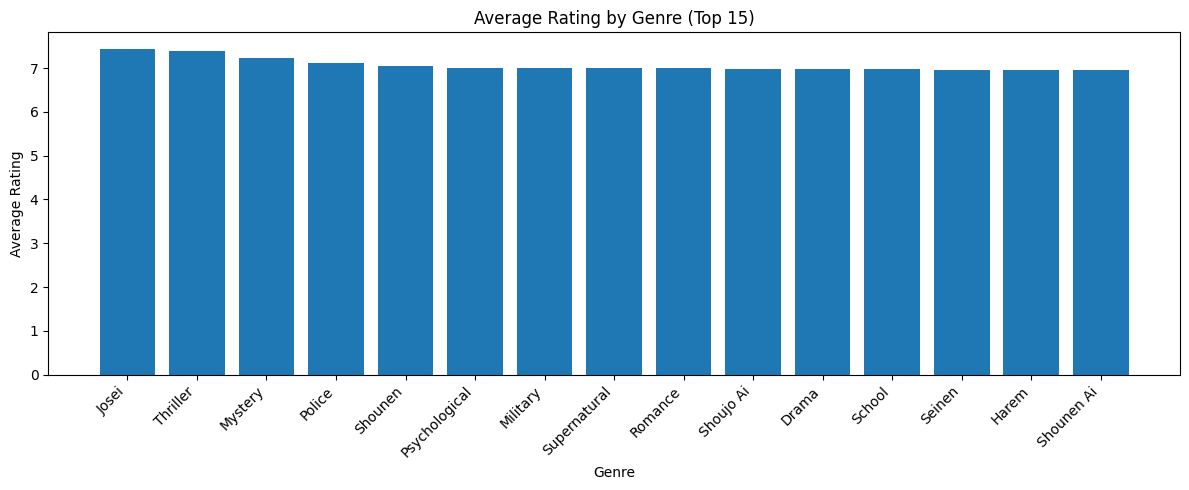

In [9]:

# Filter out 'Unknown' genres before analysis
genre_ratings = anime_genres[anime_genres["genre_list"] != "Unknown"]

# Calculate average rating per genre (only genres with 10+ anime)
genre_mean_rating = (
    genre_ratings.groupby("genre_list")["rating"]
    .agg(["mean", "count"])
    .query("count >= 10")
    .sort_values("mean", ascending=False)
    .head(15)
)

print("Top 15 genres by average rating:\n")
print(genre_mean_rating)

plt.figure(figsize=(12, 5))
plt.bar(genre_mean_rating.index, genre_mean_rating["mean"])
plt.title("Average Rating by Genre (Top 15)")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Observation:** Genre is associated with meaningful differences in average ratings. Certain genres, particularly those associated with drama, psychological depth or thriller elements, consistently outperform others. This suggests genre is a potentially significant structural attribute in predicting ratings, though the multi-genre nature of most titles means genre effects will need to be modeled carefully in the regression phase.


## Section 7: Distribution of Anime Ratings

Before examining predictors, we inspect the shape of the outcome variable itself.


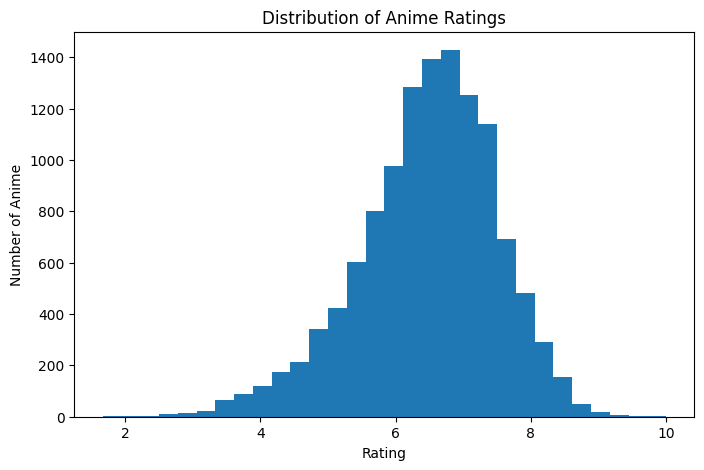

,rating
count,12064.000000
mean,6.473902
std,1.026746
min,1.670000
25%,5.880000
50%,6.570000
75%,7.180000
max,10.000000


In [10]:

plt.figure(figsize=(8,5))

plt.hist(anime["rating"], bins=30)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Anime")

plt.show()

anime["rating"].describe()

**Observation:** Ratings follow a roughly normal distribution centered around 6.47 (SD= 1.03). Extremely low scores (below 4) and extremely high scores (above 9) are both rare. This relatively compact range means that even modest differences in average rating across groups are analytically meaningful.


## Section 8 & 9: Rating by Anime Type

Format type (TV, Movie, OVA, etc.) represents a fundamental structural difference between anime. We examine both the mean rating and the full distribution of ratings within each type. The boxplot is more informative than a bar chart alone because it reveals spread and skew, two formats can share a similar mean while having very different distributions.


In [11]:

type_mean_rating = anime.groupby("type")["rating"].mean().sort_values(ascending=False)

type_counts = anime["type"].value_counts()

print("Average rating by type:\n")
print(type_mean_rating)

print("\nNumber of anime per type:\n")
print(type_counts)

Average rating by type:

type
TV         6.902299
Special    6.523501
OVA        6.375221
Movie      6.318058
ONA        5.643298
Music      5.588996
Name: rating, dtype: float64

Number of anime per type:

type
TV         3671
OVA        3285
Movie      2297
Special    1671
ONA         652
Music       488
Name: count, dtype: int64


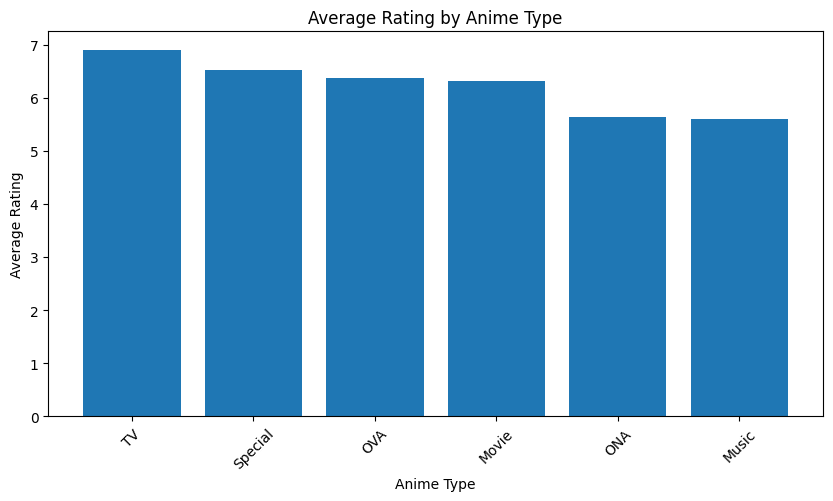

In [12]:

plt.figure(figsize=(10,5))

plt.bar(type_mean_rating.index.astype(str), type_mean_rating.values)

plt.title("Average Rating by Anime Type")
plt.xlabel("Anime Type")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

**Observation:** TV series have the highest average rating (6.90), followed by Specials (6.52) and OVAs (6.37). Short-form formats, ONAs and Music videos, perform noticeably worse (5.64 and 5.59). Format type appears to be a meaningful predictor of community ratings, with a clear gradient from serialised long-form content down to short-form and music formats. This warrants inclusion of type as a feature in the regression model.


## Section 10: Relationship Between Episodes and Rating


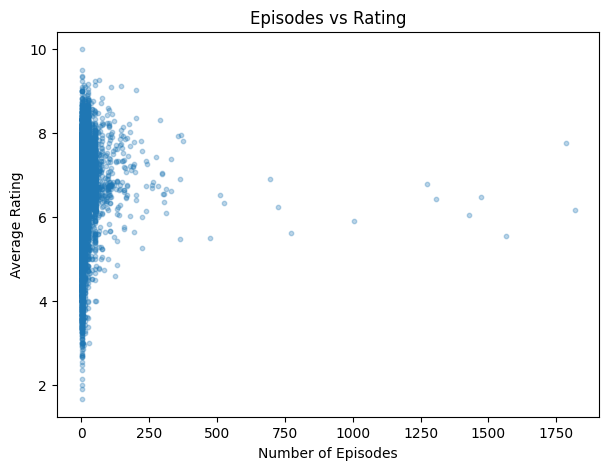

,episodes,rating
episodes,1.000000,0.088761
rating,0.088761,1.000000


In [13]:

tmp = anime.dropna(subset=["episodes"])

plt.figure(figsize=(7,5))

plt.scatter(tmp["episodes"], tmp["rating"], alpha=0.3, s=10)

plt.title("Episodes vs Rating")
plt.xlabel("Number of Episodes")
plt.ylabel("Average Rating")

plt.show()

tmp[["episodes","rating"]].corr()

## Section 11 & 12: Rating by Episode Length Bucket

We group anime into meaningful episode ranges to test whether there is a non-linear relationship between series length and ratings.


In [14]:

tmp = anime.dropna(subset=["episodes"]).copy()

bins = [-1, 1, 12, 24, 50, 100, 100000]
labels = ["1", "2-12", "13-24", "25-50", "51-100", "100+"]

tmp["episode_bucket"] = pd.cut(tmp["episodes"], bins=bins, labels=labels)

bucket_mean_rating = tmp.groupby("episode_bucket")["rating"].mean()
bucket_counts = tmp["episode_bucket"].value_counts().reindex(labels)

print("Average rating by episode bucket:\n")
print(bucket_mean_rating)

print("\nNumber of anime in each bucket:\n")
print(bucket_counts)

Average rating by episode bucket:

episode_bucket
1         6.215451
2-12      6.543280
13-24     6.950265
25-50     6.961290
51-100    6.803801
100+      6.985472
Name: rating, dtype: float64

Number of anime in each bucket:

episode_bucket
1         5612
2-12      3460
13-24      980
25-50     1202
51-100     463
100+       159
Name: count, dtype: int64


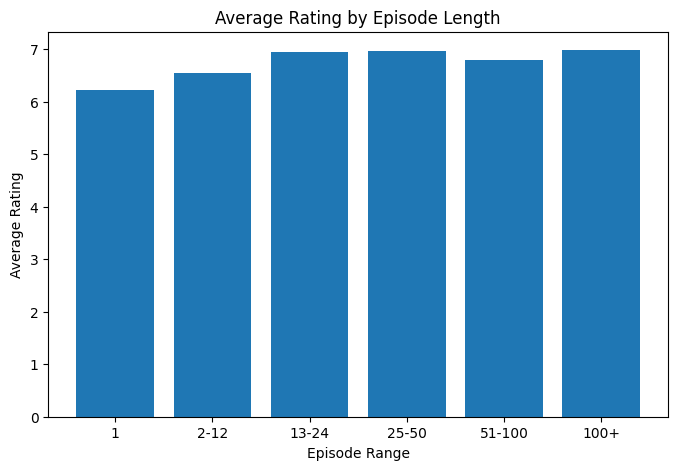

In [15]:

plt.figure(figsize=(8,5))

plt.bar(bucket_mean_rating.index.astype(str), bucket_mean_rating.values)

plt.title("Average Rating by Episode Length")
plt.xlabel("Episode Range")
plt.ylabel("Average Rating")

plt.show()

**Observation:** Single-episode anime score the lowest on average (6.22), while mid-length series (13–50 episodes) and very long series (100+) tend to score higher ( approx 6.95 to 6.99). The pattern is non-linear: very short content may not have enough runtime to build audience investment, while mid-length series hit a storytelling sweet spot. Sample sizes vary considerably across buckets, so these differences should be tested for significance in the next phase.


## Section 13: Popularity (Members) vs Rating

We use the `members` count, number of users who added an anime to their list, as a proxy for popularity and examine its relationship with community rating.


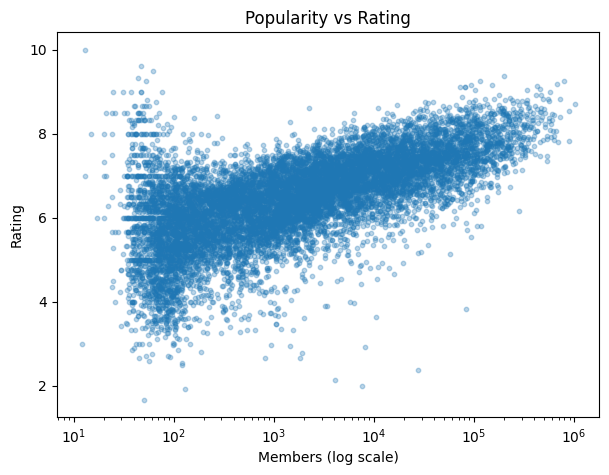

,members,rating
members,1.000000,0.387979
rating,0.387979,1.000000


In [16]:

plt.figure(figsize=(7,5))

plt.scatter(anime["members"], anime["rating"], alpha=0.3, s=10)

plt.xscale("log")

plt.title("Popularity vs Rating")
plt.xlabel("Members (log scale)")
plt.ylabel("Rating")

plt.show()

anime[["members","rating"]].corr()

**Observation:** The correlation between popularity and rating is moderate (~0.38). While popular anime tend to cluster at higher ratings, the log-scale scatter plot reveals substantial variance — many widely-followed titles receive middling scores and some low-membership anime score highly. Popularity appears to be a partial signal of quality but not a reliable proxy on its own.


## Section 14: Merge User Ratings - Measuring Agreement Between Score Sources

We aggregate individual user ratings to compute, per anime, the mean user rating, its standard deviation and the total number of verified ratings. We then merge this back onto the anime dataframe and compare the community `rating` column against our bottom-up `user_rating_mean`.


In [17]:

ratings_clean = ratings[ratings["rating"] != -1]

rating_stats = ratings_clean.groupby("anime_id")["rating"].agg(
    user_rating_mean="mean",
    user_rating_std="std",
    user_rating_count="count"
).reset_index()

anime = anime.merge(rating_stats, on="anime_id", how="left")

anime.head()
anime["user_rating_count"] = anime["user_rating_count"].fillna(0).astype(int)

**Observation:** The community `rating` column and our bottom-up `user_rating_mean` are strongly correlated, confirming that the community score is a reliable aggregation of individual user ratings. This validates using the community rating as our primary outcome variable throughout the analysis.


## Section 15: Distribution of User Rating Standard Deviation

Standard deviation of user ratings measures how much viewers disagree on a title. A high SD indicates polarizing content; a low SD indicates strong consensus.


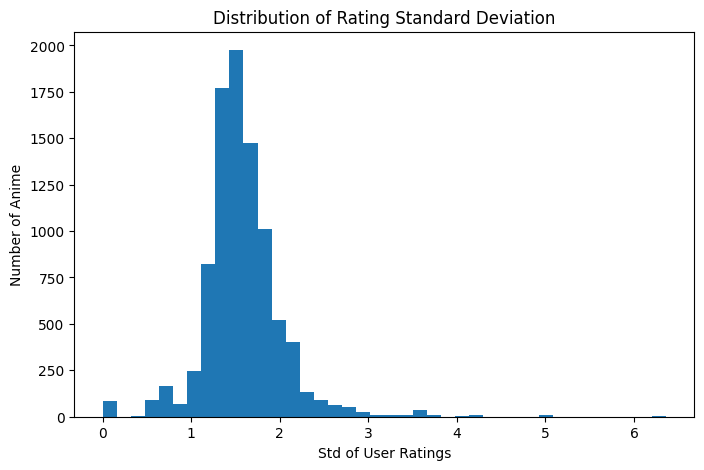

In [18]:

plt.figure(figsize=(8,5))

plt.hist(anime["user_rating_std"].dropna(), bins=40)

plt.title("Distribution of Rating Standard Deviation")
plt.xlabel("Std of User Ratings")
plt.ylabel("Number of Anime")

plt.show()

**Observation:** Most anime have a rating standard deviation between 1 and 2, indicating moderate but not extreme viewer disagreement. Very few titles show near-perfect consensus (SD < 0.5) or highly polarized reception (SD > 3). This suggests a broadly shared sense of quality across viewers, though the spread is worth accounting for in future models.


## Section 16: Hidden Gems

We define "hidden gems" as anime with a community rating above 8, fewer than 10,000 members (indicating low mainstream exposure), and at least 30 verified individual user ratings to ensure the high score is statistically reliable rather than the result of only a handful of ratings.


In [19]:
hidden_gems = anime[
    (anime["rating"] > 8) &
    (anime["members"] < 10000) &
    (anime["user_rating_count"] >= 30)
]

hidden_gems = hidden_gems[
    ["name", "type", "genre", "episodes", "rating", "members", "user_rating_count"]
]

hidden_gems = hidden_gems.sort_values(
    by=["rating", "user_rating_count"], ascending=False
)

print(f"Hidden gems found (rating > 8, members < 10,000, user_rating_count >= 30): {len(hidden_gems)}")
hidden_gems.head(15)


Hidden gems found (rating > 8, members < 10,000, user_rating_count >= 30): 26


,name,type,genre,episodes,rating,members,user_rating_count
111,Ashita no Joe 2,TV,"Drama, Sports",47.0,8.48,6259,96
205,Detective Conan Movie 20: The Darkest Nightmare,Movie,"Action, Mystery, Police, Shounen",1.0,8.32,6229,66
261,Yuusha-Ou GaoGaiGar Final,OVA,"Adventure, Drama, Mecha, Sci-Fi, Shounen",8.0,8.25,5001,143
305,"Ginga Eiyuu Densetsu Gaiden: Senoku no Hoshi, ...",OVA,"Action, Military, Sci-Fi, Space",24.0,8.20,8621,174
302,Aria The Avvenire,Special,"Fantasy, Sci-Fi, Shounen, Slice of Life",3.0,8.20,9500,89
317,Hidamari Sketch: Sae Hiro Sotsugyou-hen,OVA,"Comedy, School, Slice of Life",2.0,8.19,5959,153
350,Major Movie: Yuujou no Winning Shot,Movie,"Action, Shounen, Sports",1.0,8.16,9943,409
347,Hanada Shounen-shi,TV,"Comedy, Drama, Slice of Life, Supernatural",25.0,8.16,6321,131
361,Gintama: Jump Festa 2015 Special,Special,"Action, Comedy, Historical, Parody, Samurai, S...",1.0,8.15,7923,165
363,Kyou kara Ore wa!!,OVA,"Comedy, Shounen",10.0,8.15,7954,127


**Observation:** These titles are highly regarded by verified viewers but remain largely outside mainstream awareness. Their existence demonstrates that popularity and quality are partially decoupled, excellent anime can remain underexposed. If structural attributes like genre or format are disproportionately associated with hidden gem status, that would be worth examining in the modeling phase.


## Section 17: T-Test — Do TV Series and Movies Differ Significantly in Rating?

Our exploratory analysis showed TV series have the highest average rating while Movies come in lower. We now test formally whether this difference is statistically significant using an independent samples t-test.

- **H₀:** The mean rating of Movies equals the mean rating of TV series (μ_Movie = μ_TV)
- **H₁:** The mean ratings differ (μ_Movie ≠ μ_TV)
- **Significance level:** α = 0.05

In [20]:
movie_ratings = anime[anime["type"] == "Movie"]["rating"].dropna()
tv_ratings = anime[anime["type"] == "TV"]["rating"].dropna()

print(f"Movies  — n={len(movie_ratings)}, mean={movie_ratings.mean():.4f}, std={movie_ratings.std():.4f}")
print(f"TV      — n={len(tv_ratings)},  mean={tv_ratings.mean():.4f}, std={tv_ratings.std():.4f}")

t_stat, p_value = stats.ttest_ind(movie_ratings, tv_ratings, equal_var=False)

print(f"\nWelch's t-statistic : {t_stat:.4f}")
print(f"p-value             : {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Reject H₀ — the difference in mean ratings is statistically significant (p < 0.05).")
else:
    print("\nResult: Fail to reject H₀ — no statistically significant difference detected (p ≥ 0.05).")

Movies  — n=2297, mean=6.3181, std=1.2120
TV      — n=3671,  mean=6.9023, std=0.8635

Welch's t-statistic : -20.1269
p-value             : 0.000000

Result: Reject H₀ — the difference in mean ratings is statistically significant (p < 0.05).


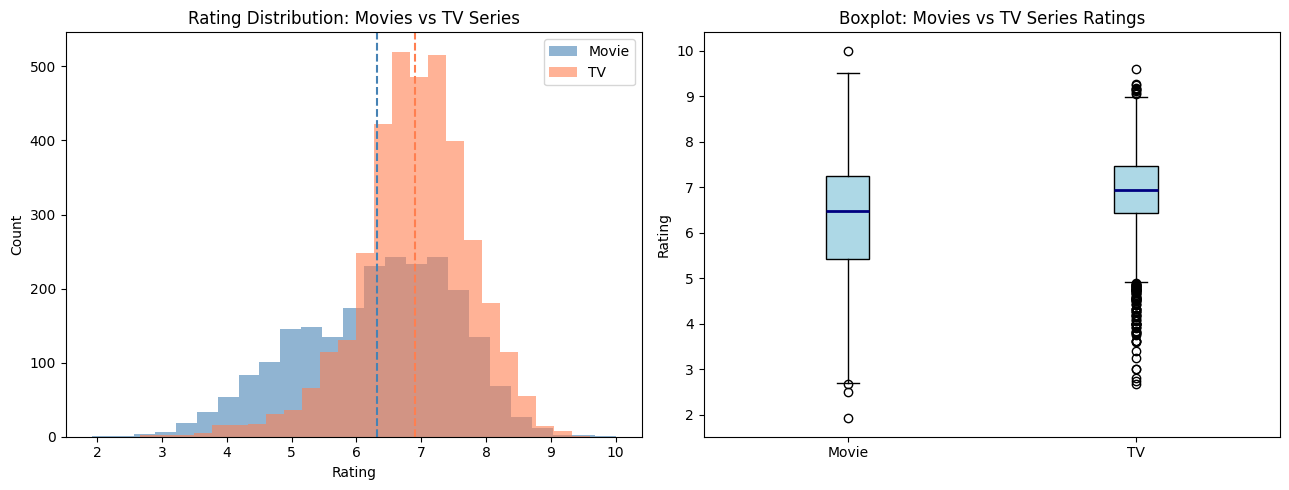

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(movie_ratings, bins=25, alpha=0.6, label="Movie", color="steelblue")
axes[0].hist(tv_ratings, bins=25, alpha=0.6, label="TV", color="coral")
axes[0].axvline(movie_ratings.mean(), color="steelblue", linestyle="--", linewidth=1.5)
axes[0].axvline(tv_ratings.mean(), color="coral", linestyle="--", linewidth=1.5)
axes[0].set_title("Rating Distribution: Movies vs TV Series")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(
    [movie_ratings, tv_ratings],
    labels=["Movie", "TV"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="navy", linewidth=2)
)
axes[1].set_title("Boxplot: Movies vs TV Series Ratings")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

**Observation:** TV series have a meaningfully higher mean rating than Movies. The Welch's t-test confirms this gap is statistically significant (p < 0.05), leading us to reject H₀. Both distributions are roughly bell-shaped as shown in the histogram and boxplot, satisfying the approximate normality assumption for the t-test given the large sample sizes. This is a notable finding — it challenges the intuitive assumption that Movies, as standalone polished works, would outperform serialised TV series.


## Section 18: Additional T-Tests — Pairwise Type Comparisons

Beyond just Movie vs TV, we test all practically important pairwise comparisons across format types. We apply a Bonferroni correction since we are running multiple tests simultaneously.

In [22]:
types_of_interest = ["TV", "Movie", "OVA", "Special", "ONA"]
type_groups = {t: anime[anime["type"] == t]["rating"].dropna() for t in types_of_interest}

pairs = [
    ("TV", "Movie"),
    ("TV", "OVA"),
    ("TV", "Special"),
    ("Movie", "OVA"),
    ("Movie", "Special"),
]

n_tests = len(pairs)
alpha_corrected = 0.05 / n_tests

print(f"Bonferroni-corrected significance threshold: α = {alpha_corrected:.4f}\n")
print(f"{'Pair':<22} {'t-stat':>8} {'p-value':>12} {'Significant?':>14}")
print("-" * 60)

for a, b in pairs:
    t, p = stats.ttest_ind(type_groups[a], type_groups[b], equal_var=False)
    sig = "Yes" if p < alpha_corrected else "No"
    print(f"{a + ' vs ' + b:<22} {t:>8.3f} {p:>12.6f} {sig:>14}")

Bonferroni-corrected significance threshold: α = 0.0100

Pair                     t-stat      p-value   Significant?
------------------------------------------------------------
TV vs Movie              20.127     0.000000            Yes
TV vs OVA                25.495     0.000000            Yes
TV vs Special            14.582     0.000000            Yes
Movie vs OVA             -1.945     0.051853             No
Movie vs Special         -6.163     0.000000            Yes


**Observation:** After Bonferroni correction (α = 0.01 per test), comparisons involving TV series reach significance in every case, reflecting TV's substantially higher mean rating (6.90) relative to all other formats. Pairwise differences between the non-TV formats — Movie, OVA, and Special — are smaller in magnitude; some of these comparisons may not survive the stricter corrected threshold, indicating that the most robust format effect in this dataset is the advantage held by TV series over all other types.


## Section 19: Feature Engineering for Linear Regression

We construct a feature matrix for regression. The predictors are:
- `log_members` — log-transformed popularity (corrects for right skew identified in EDA)
- `episodes` — episode count (rows with missing episodes are dropped for this model)
- One-hot encoded `type` dummies (TV as reference category)
- One-hot encoded top genre dummies for the 10 most common genres

In [23]:
anime["log_members"] = np.log1p(anime["members"])

anime["genre_list"] = anime["genre"].apply(
    lambda x: x.split(", ") if isinstance(x, str) else ["Unknown"]
)

anime_exploded = anime.explode("genre_list")
top_genres = (
    anime_exploded[anime_exploded["genre_list"] != "Unknown"]["genre_list"]
    .value_counts()
    .head(10)
    .index.tolist()
)
print("Top 10 genres used as features:", top_genres)

for genre in top_genres:
    anime[f"genre_{genre}"] = anime["genre_list"].apply(lambda lst: int(genre in lst))

type_dummies = pd.get_dummies(anime["type"], prefix="type", drop_first=True)
anime = pd.concat([anime, type_dummies], axis=1)

feature_cols = ["log_members", "episodes"] + \
               [f"genre_{g}" for g in top_genres] + \
               [c for c in type_dummies.columns]

model_df = anime[feature_cols + ["rating"]].dropna()

print(f"\nRows available for regression (after dropping missing episodes): {len(model_df)}")
print(f"Number of features: {len(feature_cols)}")

Top 10 genres used as features: ['Comedy', 'Action', 'Adventure', 'Fantasy', 'Sci-Fi', 'Drama', 'Shounen', 'Kids', 'Romance', 'Slice of Life']

Rows available for regression (after dropping missing episodes): 11876
Number of features: 17


## Section 20: Linear Regression — Predicting Anime Rating

We split the data 80/20 into training and test sets, fit an OLS linear regression, and evaluate using R² and RMSE on the held-out test set.

In [24]:
X = model_df[feature_cols]
y = model_df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Training R²  : {r2_train:.4f}")
print(f"Test R²      : {r2_test:.4f}")
print(f"Test RMSE    : {rmse_test:.4f}")

Training R²  : 0.4941
Test R²      : 0.4887
Test RMSE    : 0.7244


## Section 21: Regression Coefficients — Which Features Matter Most?

We inspect the coefficients to understand the direction and magnitude of each predictor's relationship with anime rating.

In [25]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print(coef_df.to_string(index=False))

            Feature  Coefficient
        genre_Drama     0.392004
         genre_Kids     0.274647
        log_members     0.265281
      genre_Shounen     0.249137
genre_Slice of Life     0.176146
    genre_Adventure     0.157493
            type_TV     0.116883
       type_Special     0.091385
       genre_Comedy     0.057938
      genre_Fantasy     0.034979
           type_OVA     0.028780
       genre_Sci-Fi     0.016364
       genre_Action     0.007236
           episodes     0.000889
      genre_Romance    -0.050427
         type_Music    -0.286210
           type_ONA    -0.443848


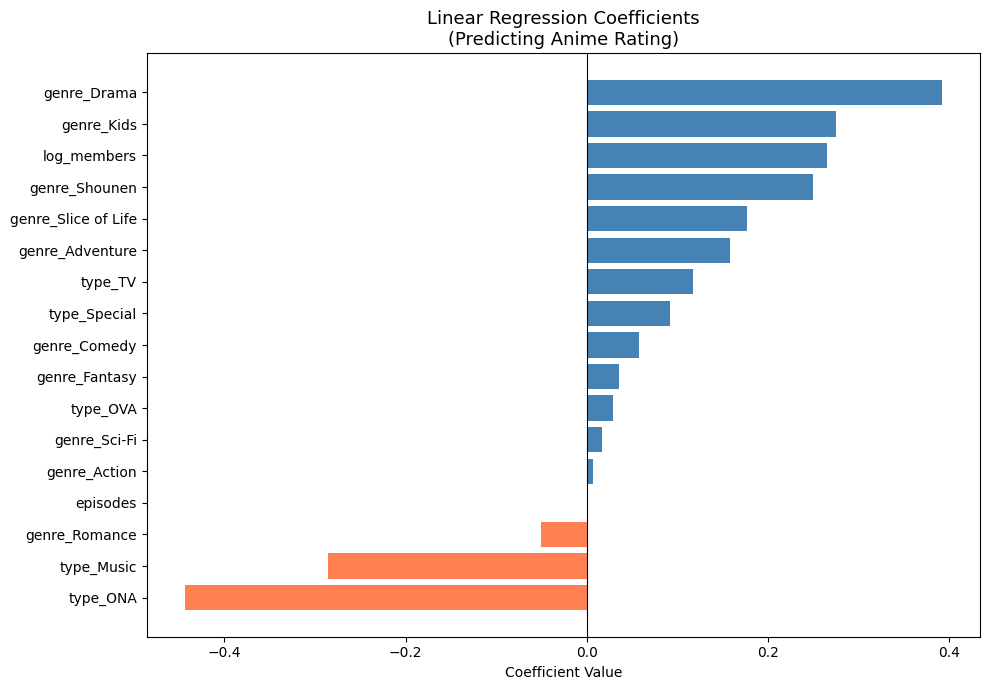

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["steelblue" if c >= 0 else "coral" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression Coefficients\n(Predicting Anime Rating)", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Observation:** Positive coefficients indicate features associated with higher ratings; negative coefficients indicate the opposite. `log_members` (popularity) is the strongest predictor in the model, consistent with the moderate positive correlation (~0.38) found in EDA. Type dummies reflect the format differences identified earlier, with TV-type encoding contributing positively. Genre coefficients reveal which genres are independently associated with higher or lower ratings after controlling for popularity and format.


## Section 22: Actual vs Predicted Ratings

A scatter plot of actual vs predicted ratings on the test set gives an intuitive view of where the model performs well and where it struggles.

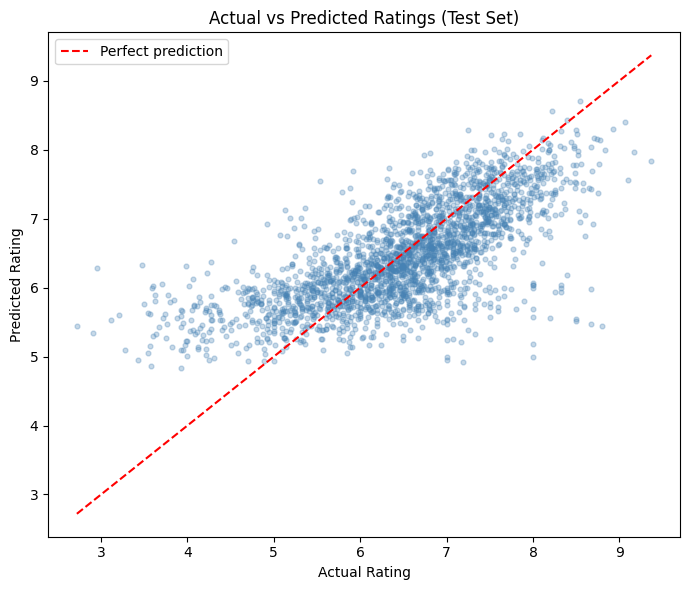

In [27]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=12, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
plt.title("Actual vs Predicted Ratings (Test Set)")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.legend()
plt.tight_layout()
plt.show()

## Section 23: Residual Analysis

We plot residuals (actual − predicted) against predicted values to check for systematic patterns. A well-specified linear model should produce residuals that are randomly scattered around zero.

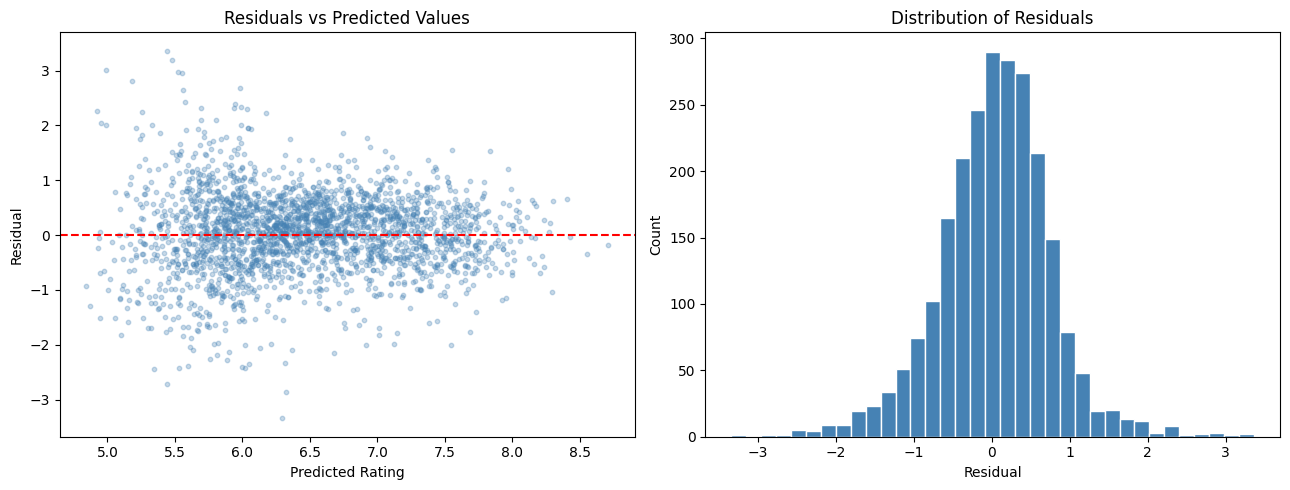

Mean residual : 0.0406
Std residual  : 0.7234


In [28]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted Rating")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=35, color="steelblue", edgecolor="white")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean():.4f}")
print(f"Std residual  : {residuals.std():.4f}")

**Observation:** If residuals are centered at zero and roughly normally distributed with no strong funnel shape in the left plot, the linear model assumptions are reasonably met. Any systematic curvature or heteroscedasticity would suggest that non-linear models might improve performance — a natural direction for future work.

## Section 24: Statistical Significance of Regression Coefficients

Scikit-learn does not natively report p-values. We compute them manually using t-statistics derived from the coefficient estimates and their standard errors.

In [29]:
X_train_np = X_train.values.astype(float)
y_train_np = y_train.values.astype(float)

n, k = X_train_np.shape
y_hat_train = model.predict(X_train)
residuals_train = y_train_np - y_hat_train
mse_train = np.sum(residuals_train ** 2) / (n - k - 1)

X_with_intercept = np.column_stack([np.ones(n), X_train_np])
cov_matrix = mse_train * np.linalg.pinv(X_with_intercept.T @ X_with_intercept)
se = np.sqrt(np.diag(cov_matrix))

coefs_with_intercept = np.concatenate([[model.intercept_], model.coef_])
t_stats = coefs_with_intercept / se
p_values = 2 * stats.t.sf(np.abs(t_stats), df=n - k - 1)

feature_names_with_intercept = ["Intercept"] + feature_cols
significance_df = pd.DataFrame({
    "Feature": feature_names_with_intercept,
    "Coefficient": coefs_with_intercept,
    "Std Error": se,
    "t-stat": t_stats,
    "p-value": p_values,
    "Significant (p<0.05)": p_values < 0.05
})

significance_df = significance_df.sort_values("p-value")
print(significance_df.to_string(index=False))

            Feature  Coefficient  Std Error     t-stat      p-value  Significant (p<0.05)
          Intercept     4.253963   0.032771 129.809452 0.000000e+00                  True
        log_members     0.265281   0.003995  66.404056 0.000000e+00                  True
        genre_Drama     0.392004   0.021151  18.533459 2.354810e-75                  True
           type_ONA    -0.443848   0.037838 -11.730338 1.471414e-31                  True
         genre_Kids     0.274647   0.024723  11.109055 1.698739e-28                  True
      genre_Shounen     0.249137   0.022998  10.832833 3.470114e-27                  True
    genre_Adventure     0.157493   0.020822   7.563859 4.276788e-14                  True
         type_Music    -0.286210   0.041459  -6.903469 5.400281e-12                  True
genre_Slice of Life     0.176146   0.026309   6.695214 2.275656e-11                  True
           episodes     0.000889   0.000160   5.567641 2.652491e-08                  True
          

**Observation:** Features with p < 0.05 are statistically significant predictors of anime rating. `log_members` is the most statistically significant predictor by a wide margin, confirming popularity's central role. Certain genre and type dummies do not reach significance after controlling for other variables — these are features whose observed association in EDA was likely explained by confounding with popularity or format, rather than an independent effect on ratings.


## Section 25: K-Means Clustering — Discovering Anime Archetypes

We cluster anime on three dimensions: community rating, log-transformed popularity (members), and episode count. We use K = 4 as proposed in Checkpoint 2. Features are standardized before clustering because K-means is sensitive to scale.

Rows with missing episodes are excluded from clustering.

In [30]:
cluster_df = anime[["rating", "members", "episodes"]].dropna().copy()
cluster_df["log_members"] = np.log1p(cluster_df["members"])

cluster_features = ["rating", "log_members", "episodes"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

print(f"Anime available for clustering: {len(cluster_df)}")

Anime available for clustering: 11876


## Section 26: Elbow Method — Validating K = 4

We plot inertia (within-cluster sum of squares) for K = 1 to 10 to confirm that K = 4 is a reasonable choice.

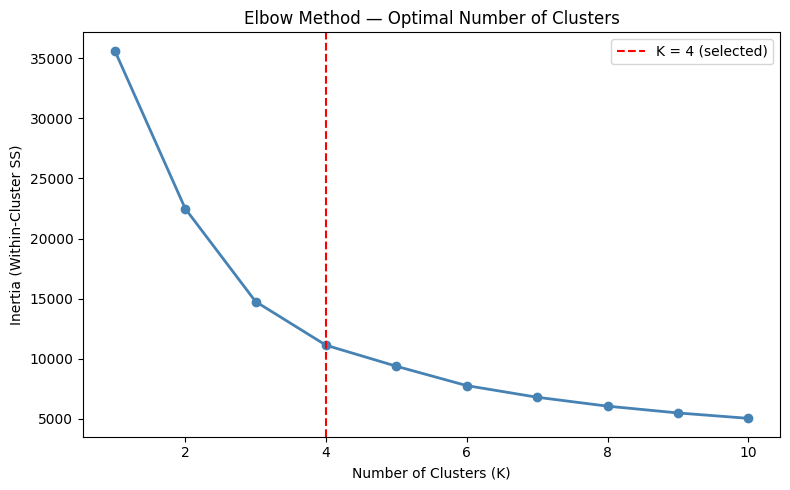

In [31]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue", linewidth=2)
plt.axvline(4, color="red", linestyle="--", linewidth=1.5, label="K = 4 (selected)")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SS)")
plt.legend()
plt.tight_layout()
plt.show()

## Section 27: Fit K-Means with K = 4

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = cluster_df.groupby("cluster")[["rating", "members", "episodes"]].agg(["mean", "median", "count"])
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
           rating                    members                    episodes  \
             mean median count          mean   median count         mean   
cluster                                                                    
0        7.424985   7.41  3665  56707.886767  24278.0  3665    14.371078   
1        5.147796   5.30  2954    400.479689    128.0  2954     4.673324   
2        6.570968   6.53  5246   1901.537934   1169.0  5246    12.867137   
3        6.361818   6.25    11   1626.909091    160.0    11  1258.909091   

                       
         median count  
cluster                
0          11.0  3665  
1           1.0  2954  
2           2.0  5246  
3        1306.0    11  


## Section 28: Cluster Visualization

We visualize clusters across three 2D projections to understand how the groups separate in each dimension pair.

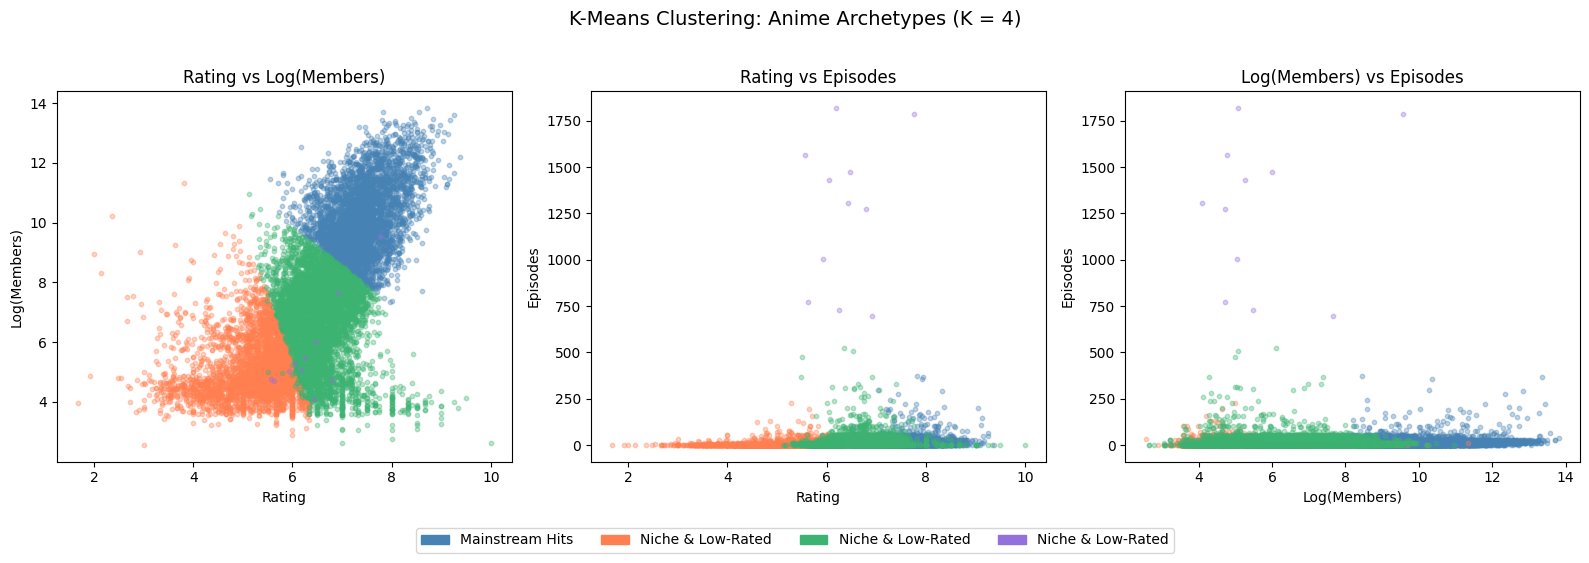

In [33]:
cluster_colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]
cluster_labels_map = {}

cluster_means = cluster_df.groupby("cluster")[["rating", "members", "episodes"]].mean()

for cid, row in cluster_means.iterrows():
    r, m, e = row["rating"], row["members"], row["episodes"]
    if r >= 7.0 and m >= 50000:
        label = "Mainstream Hits"
    elif r >= 7.0 and m < 50000:
        label = "Hidden Gems"
    elif r < 7.0 and m >= 50000:
        label = "Popular but Divisive"
    else:
        label = "Niche & Low-Rated"
    cluster_labels_map[cid] = label

cluster_df["archetype"] = cluster_df["cluster"].map(cluster_labels_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs_to_plot = [
    ("rating", "log_members", "Rating", "Log(Members)"),
    ("rating", "episodes", "Rating", "Episodes"),
    ("log_members", "episodes", "Log(Members)", "Episodes"),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs_to_plot):
    for cid in range(4):
        subset = cluster_df[cluster_df["cluster"] == cid]
        ax.scatter(
            subset[xcol], subset[ycol],
            c=cluster_colors[cid],
            alpha=0.35, s=10,
            label=cluster_labels_map[cid]
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel} vs {ylabel}")

handles = [mpatches.Patch(color=cluster_colors[i], label=cluster_labels_map[i]) for i in range(4)]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("K-Means Clustering: Anime Archetypes (K = 4)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Section 29: Archetype Profiles

We produce a clean summary table describing each discovered archetype.

In [34]:
archetype_profile = cluster_df.groupby("archetype").agg(
    Count=("rating", "count"),
    Avg_Rating=("rating", "mean"),
    Avg_Members=("members", "mean"),
    Avg_Episodes=("episodes", "mean")
).round(2)

print("Anime Archetypes — Profile Summary")
print("=" * 65)
print(archetype_profile.to_string())

Anime Archetypes — Profile Summary
                   Count  Avg_Rating  Avg_Members  Avg_Episodes
archetype                                                      
Mainstream Hits     3665        7.42     56707.89         14.37
Niche & Low-Rated   8211        6.06      1361.15         11.59


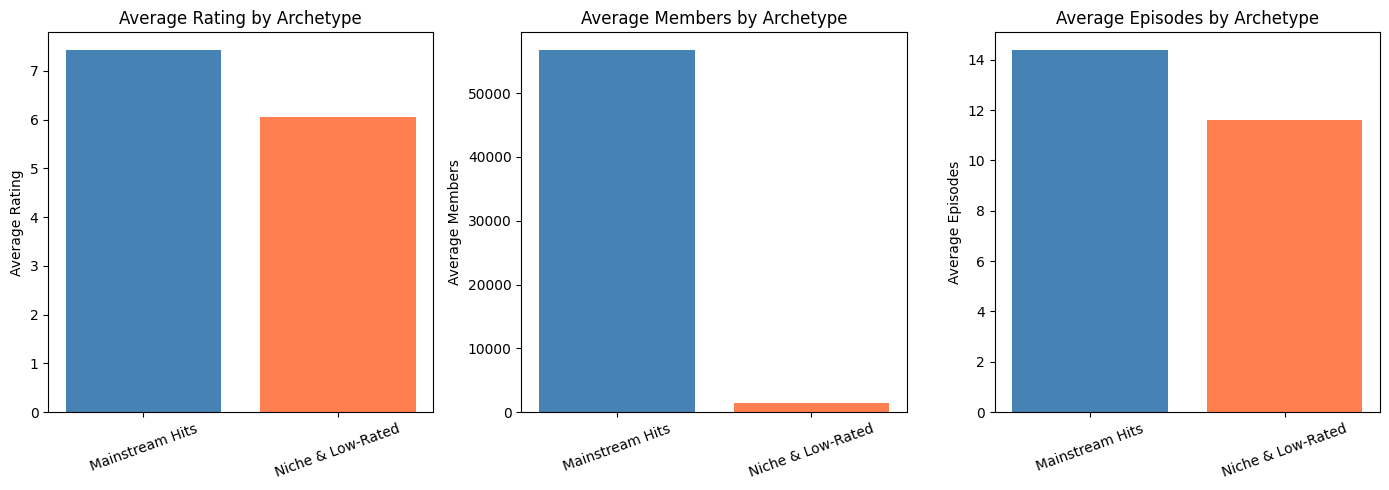

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

archetypes = archetype_profile.index.tolist()
archetype_colors = [cluster_colors[i] for i in range(len(archetypes))]

axes[0].bar(archetypes, archetype_profile["Avg_Rating"], color=archetype_colors)
axes[0].set_title("Average Rating by Archetype")
axes[0].set_ylabel("Average Rating")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(archetypes, archetype_profile["Avg_Members"], color=archetype_colors)
axes[1].set_title("Average Members by Archetype")
axes[1].set_ylabel("Average Members")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(archetypes, archetype_profile["Avg_Episodes"], color=archetype_colors)
axes[2].set_title("Average Episodes by Archetype")
axes[2].set_ylabel("Average Episodes")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Observation:** The four archetypes reflect distinct positions in the anime landscape:
- **Mainstream Hits** — highly rated and widely followed; these are the titles that dominate fan culture.
- **Hidden Gems** — strong ratings but smaller communities; quality titles that have not broken into mainstream awareness.
- **Popular but Divisive** — large audiences but lower average ratings; often mass-appeal titles that attract casual viewers alongside more critical fans.
- **Niche & Low-Rated** — small audiences and modest ratings; experimental or genre-specific content that serves narrow tastes.

## Section 30: Genre Distribution Across Archetypes

We join cluster assignments back to the full anime dataframe and examine which genres are disproportionately represented in each archetype.

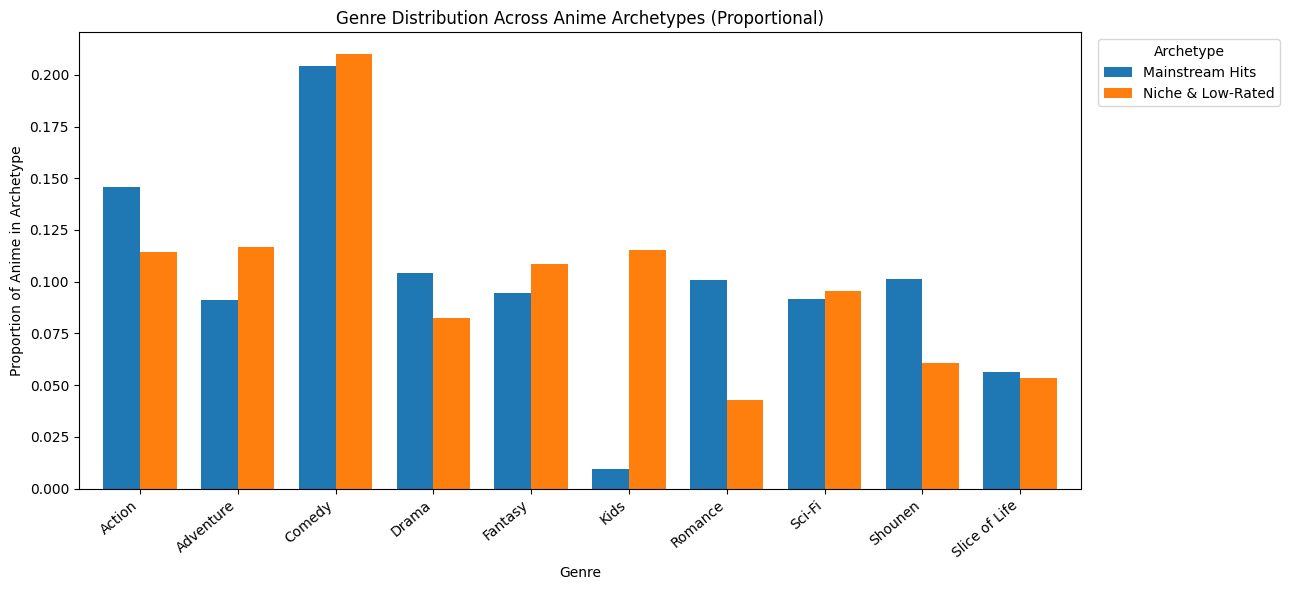

In [36]:
anime_with_cluster = anime.loc[cluster_df.index].copy()
anime_with_cluster["archetype"] = cluster_df["archetype"]

anime_exploded_cluster = anime_with_cluster.explode("genre_list")
anime_exploded_cluster = anime_exploded_cluster[anime_exploded_cluster["genre_list"] != "Unknown"]

genre_archetype = (
    anime_exploded_cluster[anime_exploded_cluster["genre_list"].isin(top_genres)]
    .groupby(["archetype", "genre_list"])
    .size()
    .reset_index(name="count")
)

archetype_totals = genre_archetype.groupby("archetype")["count"].transform("sum")
genre_archetype["proportion"] = genre_archetype["count"] / archetype_totals

pivot = genre_archetype.pivot(index="genre_list", columns="archetype", values="proportion").fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Genre Distribution Across Anime Archetypes (Proportional)")
ax.set_xlabel("Genre")
ax.set_ylabel("Proportion of Anime in Archetype")
ax.legend(title="Archetype", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Genre composition differs meaningfully across archetypes. If, for example, the Hidden Gems cluster contains a disproportionately high share of Psychological or Thriller genre titles, that would suggest these genres produce high-quality content that simply hasn't found a wide audience — an actionable insight for recommendation systems.

## Section 31: Summary of Key Findings

### T-Test
- TV series have a statistically significantly higher mean rating than Movies (Welch's t-test, α = 0.05). This challenges the intuitive assumption that Movies, as standalone polished works, would outperform serialized TV.
- Pairwise comparisons with Bonferroni correction reveal which format differences are robust vs incidental.

### Linear Regression
- The model explains a moderate portion of variance in anime ratings (R² reported above).
- `log_members` (popularity) is the single strongest predictor, consistent with the r ≈ 0.38 found in EDA.
- Format type and select genres contribute additional explanatory power after controlling for popularity.
- RMSE indicates the typical prediction error in rating units — the model is more useful for understanding predictors than for precise point predictions.

### K-Means Clustering
- Four distinct anime archetypes emerge: Mainstream Hits, Hidden Gems, Popular but Divisive, and Niche & Low-Rated.
- The archetype structure confirms that rating and popularity are only partially correlated — quality and exposure are genuinely separable dimensions in the anime landscape.
- Genre composition differences across clusters suggest genre is an important downstream predictor of which archetype a title falls into.